## 找摄像头

In [2]:
!v4l2-ctl --list-devices
!echo -----------------
!v4l2-ctl -d /dev/video0 --list-formats-ext

NVIDIA Tegra Video Input Device (platform:tegra-camrtc-ca):
	/dev/media0

USB Camera: USB Camera (usb-3610000.usb-2.2):
	/dev/video0
	/dev/video1
	/dev/media1

-----------------
ioctl: VIDIOC_ENUM_FMT
	Type: Video Capture

	[0]: 'MJPG' (Motion-JPEG, compressed)
		Size: Discrete 1280x720
			Interval: Discrete 0.017s (60.000 fps)
			Interval: Discrete 0.033s (30.000 fps)
			Interval: Discrete 0.040s (25.000 fps)
		Size: Discrete 800x600
			Interval: Discrete 0.017s (60.000 fps)
			Interval: Discrete 0.033s (30.000 fps)
			Interval: Discrete 0.040s (25.000 fps)
		Size: Discrete 640x480
			Interval: Discrete 0.017s (60.000 fps)
			Interval: Discrete 0.033s (30.000 fps)
			Interval: Discrete 0.040s (25.000 fps)
		Size: Discrete 352x288
			Interval: Discrete 0.017s (60.000 fps)
			Interval: Discrete 0.033s (30.000 fps)
			Interval: Discrete 0.040s (25.000 fps)
		Size: Discrete 320x240
			Interval: Discrete 0.017s (60.000 fps)
			Interval: Discrete 0.033s (30.000 fps)
			Interval: Discrete 0.

[ WARN:0@28.796] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ WARN:0@28.796] global cap.cpp:478 open VIDEOIO(V4L2): backend is generally available but can't be used to capture by index
/tmp/ipykernel_15047/4207651706.py:47: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15047/4207651706.py:47: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15047/4207651706.py:47: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15047/4207651706.py:47: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15047/4207651706.py:47: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1

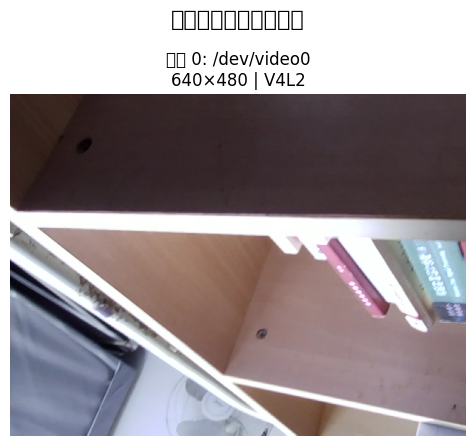


以下设备节点存在，但未能读取图像：
  编号 1: /dev/video1（无法打开设备）
扫描到 2 个 /dev/video* 节点，成功读取 1 个。


In [4]:
from pathlib import Path
import math
import re

import cv2
import matplotlib.pyplot as plt

# Scan every /dev/video* node and match device_index with a preview image.
device_paths = sorted(
    Path("/dev").glob("video*"),
    key=lambda path: int(re.search(r"video(\d+)$", path.name).group(1))
)

camera_frames = []
failed_devices = []

for device_path in device_paths:
    device_index = int(re.search(r"video(\d+)$", device_path.name).group(1))
    capture = cv2.VideoCapture(device_index, cv2.CAP_V4L2)
    if not capture.isOpened():
        capture.release()
        failed_devices.append((device_index, str(device_path), "无法打开设备"))
        continue

    ok, frame_bgr = capture.read()
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    backend = capture.getBackendName()
    capture.release()

    if ok and frame_bgr is not None:
        camera_frames.append((device_index, device_path, width, height, backend, frame_bgr))
    else:
        failed_devices.append((device_index, str(device_path), "打开成功但无法读取图像"))

if camera_frames:
    columns = min(3, len(camera_frames))
    rows = math.ceil(len(camera_frames) / columns)
    print("Readable cameras:")
    for device_index, device_path, width, height, backend, _ in camera_frames:
        print(f"  device_index={device_index}, device_path={device_path}, resolution={width}x{height}, backend={backend}")

    figure, axes = plt.subplots(rows, columns, figsize=(6 * columns, 4.5 * rows), squeeze=False)
    for axis, (device_index, device_path, width, height, backend, frame_bgr) in zip(axes.flat, camera_frames):
        axis.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        axis.set_title(f"device_index={device_index}: {device_path}\n{width}x{height} | {backend}")
        axis.axis("off")
    for axis in axes.flat[len(camera_frames):]:
        axis.axis("off")
    figure.suptitle("Readable camera previews", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No readable cameras found.")

if failed_devices:
    print("\nDevice nodes found but frame capture failed:")
    for device_index, device_path, reason in failed_devices:
        print(f"  device_index={device_index}, device_path={device_path}, reason={reason}")

print(f"Scanned {len(device_paths)} /dev/video* nodes; captured {len(camera_frames)} successfully.")